In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dimitrinovareze/moliere2/moliere.txt


In [11]:
import numpy as np
# joli affichage du modèle *m*
def summary(m):
    total_p = 0
    for i, p in enumerate(m.parameters()):
        num_p = np.prod(p.shape)
        if p.requires_grad:
            trainable = "entrainables"
        else:
            trainable = "figés"
        print(f"Couche {i}: {list(p.shape)} (\x1b[34m{num_p}\x1b[0m paramètres {trainable})")
        total_p += num_p
    print(f"  = \x1b[31m{total_p}\x1b[0m paramètres entrainables")



def summary_perso(m):
    total_p = 0
    for i, p in enumerate(m.parameters()):
        num_p = np.prod(p.shape)
        if p.requires_grad:
            trainable = "entrainables"
        else:
            trainable = "figés"
        total_p += num_p
    return total_p

In [12]:
# Cours sur la compréhension d'un décodeur de type GPT
# MSO 3ème année de l'option Information
# Ecole Centrale de Lyon
# Julien VELCIN

# Ce script correspondant à une implémentation complète d'un décodeur de type GPT
# Il est directement inspiré de la vidéo "Let's build GPT: from scratch, in code, spelled out" d'A. Karpathy (Director of AI at Tesla, OpenAI)
# https://www.youtube.com/watch?v=kCc8FmEb1nY
# Voir aussi son implémentation appelée NanoGPT : https://github.com/karpathy/nanoGPT (sous licence MIT)

# on rajoute ici :
# - normalisation de couche (layer normalization)
# - connections résiduelles (residual connections)
# - plusieurs blocs Transformer (stack of Transformer blocks)

# chargement des données

import torch
import torch.nn as nn
import torch.nn.functional as F
import re

#hyperparameters



###################
batch_size = 32  # nombre de séquences traitées en parallèle
block_size = 64  # context length: combien de caractères allons-nous regarder pour prédire
max_iters = 5000
eval_interval = 300
learning_rate = 1e-3
eval_iters = 200
n_embd = 256  # taille des embeddings
n_block = 6  # Ajout de l'hyperparametre du nombre de block et du nombre de tete d'attention
n_head = 8
#####################





# accélération à l'aide d'un GPU (ou pas...)
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

torch.manual_seed(1337)

# chargement des données
with open("/kaggle/input/datasets/dimitrinovareze/moliere2/moliere.txt", "r", encoding="utf-8") as file:
    text = file.read()



def clean_corpus(raw_text):
    cleaned = re.sub(r' {2,}', ' ', raw_text)
    cleaned = re.sub(r'\n{3,}', '\n\n', cleaned)
    # Supprime les espaces restants en tout début ou toute fin de ligne
    cleaned = re.sub(r'(?m)^ +| +$', '', cleaned)
    cleaned = cleaned.replace('\t', ' ')
    return cleaned
    
text = clean_corpus(text)



# construction du vocabulaire (ici, les caractères uniques dans le texte), qu'on appelle un codebook
chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}   
encode = lambda s: [stoi[c] for c in s] # encoder: str -> list of int
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: list of int -> str

# encodage du dataset
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))  # 90% pour le train
train_data = data[:n]
val_data = data[n:]

def get_batch(split):
    # génère un batch de données
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

@torch.no_grad() # pas de backpropagation dans cette fonction, on ne fait qu'évaluer
def estimate_loss():
    out = {}
    model.eval() # mode évaluation
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, y = get_batch(split)
            logits, loss = model(X, y)
            losses[k] = loss.item()
        avg_loss = losses.mean()
        out[split] = avg_loss
        out[f"{split}_ppl"] = torch.exp(torch.tensor(avg_loss)).item()    #On ajoute la perplexité ici !
    model.train() # mode entraînement (ici, ne sert à rien car on n'a pas de dropout ou batchnorm)
    return out

# ajout d'une classe pour gérer la self attention
class Head(nn.Module):
    # gère une seule tête d'attention
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        # register_buffer permet de stocker un tensor qui n'est pas un paramètre entraînable 
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)   # (B,T,C), avec C = head_size
        q = self.query(x) # (B,T,C), avec C = head_size
        v = self.value(x) # (B,T,C), avec C = head_size
        # calcule le score d'attention (attention maps)
        wei = q @ k.transpose(-2,-1) * C**-0.5  # (B,T,T), **-0.5 = racine carrée
        wei = wei.masked_fill(self.tril[:T,:T] == 0, float('-inf')) # (B,T,T)
        # attention, ici on est obligé de "couper" la matrice pour correspondre à la taille de la séquence
        # car celle-ci peut être plus petite que block_size lors de la génération
        wei = torch.softmax(wei, dim=-1)
        out = wei @ v  # (B,T,T) @ (B,T,C) -->  (B,T,C)
        return out

# classe pour gérer plusieurs têtes d'attention
class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.proj(out)
        return out
    
# deux couches feedforward exécutées pour chaque token indépendamment
class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
        )

    def forward(self, x):
        return self.net(x)

# classe pour un bloc Transformer
class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        # version 1 :
        #x = self.sa(x) 
        #x = self.ffwd(x)
        # version 2 = avec connections résiduelles / skip connections
        #x = x + self.sa(x)
        #x = x + self.ffwd(x)
        # version 3 = avec connections résiduelles *et* layer normalization
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        # à noter que l'ordre exact des opérations d'addition, normalisation...
        # n'est pas exactement le même que celui du Transformer original,
        # mais c'est une variante qui fonctionne très bien et plus simple à implémenter
        return x

class myGPT(nn.Module):
    def __init__(self):
        super().__init__()
        # les embeddings (lookup table) :
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        # plus un embedding positionnel :
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        # ici on modifie pour avoir de l'attention multi-têtes
        self.blocks = nn.Sequential(
            *[Block(n_embd,n_head) for _ in range(n_block)],
            nn.LayerNorm(n_embd)
        )
        # ajout d'une couche linéaire pour projeter les embeddings vers le vocabulaire
        self.lm_head = nn.Linear(n_embd, vocab_size)  

    def forward(self, idx, targets=None):
        B, T = idx.shape # on récupère les dimensions du batch et de la séquence
        # idx et targets sont des tensors de forme (B, T) où B est le batch size et T la séquence length
        tok_emb = self.token_embedding_table(idx)  # (B, T, C) où C est la dimension des embeddings (n_embd)
        # ajout des embeddings positionnels
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))  # (T, C)
        x = tok_emb + pos_emb  # (B, T, C)
        # appliquer les blocs Transformer définis dans self.blocks
        x = self.blocks(x)  # (B, T, C)
        logits = self.lm_head(x)  # (B, T, vocab_size) 

        if targets is None: # nécessaire pour la génération de texte (càd sans vérité terrain)
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C) # à expliquer (illustration)
            targets = targets.view(B*T) # à expliquer (illustration)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx est un tensor de forme (B, T)
        for _ in range(max_new_tokens):
            # couper le contexte pour avoir maximum block_size tokens
            idx_cond = idx[:, -block_size:]  # (B, block_size) 
            # on demande la prédiction du prochain token
            logits, _ = self(idx_cond) # (B, T, C)
            logits = logits[:, -1, :]  # prendre les logits du dernier token (B, C), -1 sélectionne le dernier élément de la 2ème dimension (le temps)
            probs = F.softmax(logits, dim=-1)  # (B, C), on calcule la proba sur la dernière dimension (les classes)
            next_idx = torch.multinomial(probs, num_samples=1)  # (B, 1)
            idx = torch.cat((idx, next_idx), dim=1)  # concaténer le nouveau token à la fin de la séquence
        return idx


    def generate_BEAM(self, idx, max_new_token, k):
        idx = idx.repeat(k, 1) # (k, T)
        scores = torch.zeros(k, device=device)
        scores[1:] = -1e9 #pour pas générer que des espaces
        for _ in range(max_new_token):
            # on demande la prédiction du prochain token
            logits, _ = self(idx[:, -block_size:]) # (B, T, C)
            logits = logits[:, -1, :] # prendre les logits du dernier token (B, C), -1 sélectionne le dernier élément de la 2ème dimension (le temps)
            
            log_probs = F.log_softmax(logits, dim=-1)  # (B, C), on calcule la proba sur la dernière dimension (les classes)
            
            scores = scores.unsqueeze(1) + log_probs  #log prob de taille (k,V) et score.unsqueeze(1)


            flat_scores = scores.view(-1)
            best_score, best_idx = torch.topk(flat_scores,k)

            #best_indices contient des nombres entre 0 et (k×V)−1
            pistes_meres = best_idx // vocab_size
            lettres_choisi = best_idx % vocab_size 
           
          

            idx = idx[pistes_meres]
            nouvelle_colonne = lettres_choisi.unsqueeze(1)
            idx = torch.cat((idx, nouvelle_colonne), dim=1)


            scores = best_score

        meilleur_index = torch.argmax(scores)
        return idx[meilleur_index].unsqueeze(0)


    def genrate_BEAM_avec_penalite(self, idx, max_new_token, k):
        idx = idx.repeat(k, 1) # (k, T)
        scores = torch.zeros(k, device=device)
        for _ in range(max_new_token):
            # on demande la prédiction du prochain token
            logits, _ = self(idx[:, -block_size:]) # (B, T, C)
            logits = logits[:, -1, :] # prendre les logits du dernier token (B, C), -1 sélectionne le dernier élément de la 2ème dimension (le temps)
            
            
            repetition_penalty = 1.5 
            
            for i in range(k):
                recent_tokens = torch.unique(idx[i, -50:])
                
                for token in recent_tokens:
                    if logits[i, token] > 0:
                        logits[i, token] /= repetition_penalty
                    else:
                        logits[i, token] *= repetition_penalty
                        
                        
            log_probs = F.log_softmax(logits, dim=-1)  # (B, C), on calcule la proba sur la dernière dimension (les classes)
            
            scores = scores.unsqueeze(1) + log_probs  #log prob de taille (k,V) et score.unsqueeze(1)


            flat_scores = scores.view(-1)
            best_score, best_idx = torch.topk(flat_scores,k)

            #On aa applatit les scores, il faut retrouver les indices et les lettres de notre piste
            pistes_meres = best_idx // vocab_size
            lettres_choisi = best_idx % vocab_size 
           
          

            idx = idx[pistes_meres]
            nouvelle_colonne = lettres_choisi.unsqueeze(1)
            idx = torch.cat((idx, nouvelle_colonne), dim=1)


            scores = best_score

        meilleur_index = torch.argmax(scores)
        return idx[meilleur_index].unsqueeze(0)
        

    


### Quelques metrique (perplexité calculé dans estimate_loss)

In [29]:
## Tester sur les lettres et avoir une entropy sur la dispertions des tokens 
def calculate_lexical_diversity_word(text):
    words = text.lower().split()
    if not words: return 0
    return len(set(words))/len(words)


In [14]:
from collections import Counter

#Va nous permettre d'afficher l'histogramme de la répartitions des token dans le texte.
def calculate_lexical_diversity_token(text):
    return Counter(text)

In [15]:
def build_reference_vocab(raw_text):
    mots = re.findall(r'\b[a-zàâçéèêëîïôûùüÿæœ]+\b', raw_text.lower())
    return set(mots) 

MOLIERE_VOCAB = build_reference_vocab(text) 


def calculate_hallucination_rate(generated_text, reference_vocab):
    mots_generes = re.findall(r'\b[a-zàâçéèêëîïôûùüÿæœ]+\b', generated_text.lower())
    
    if len(mots_generes) == 0:
        return 0.0, []
        
    mots_inventes = []
    for mot in mots_generes:
        if mot not in reference_vocab:
            mots_inventes.append(mot)
        
    taux = len(mots_inventes) / len(mots_generes)
    
    return taux, mots_inventes

In [30]:
# chargement des données
with open("/kaggle/input/datasets/dimitrinovareze/moliere2/moliere.txt", "r", encoding="utf-8") as file:
    text = file.read()


text = clean_corpus(text)

calculate_lexical_diversity_word(text)

0.12788775444582728

## Test de plusieurs hyperparametres

In [16]:
import time
configs_to_test = [
    {"nom": "m1", "n_embd": 64,  "n_head": 4, "n_block": 3, "block_size": 16},
    {"nom": "m2", "n_embd": 64,  "n_head": 4, "n_block": 3, "block_size": 64},
    {"nom": "m3", "n_embd": 128, "n_head": 4, "n_block": 3, "block_size": 64},
    {"nom": "m4", "n_embd": 128, "n_head": 4, "n_block": 6, "block_size": 64},
    {"nom": "m5", "n_embd": 128, "n_head": 8, "n_block": 3, "block_size": 64},
    {"nom": "m6", "n_embd": 128, "n_head": 4, "n_block": 3, "block_size": 128},    
    {"nom": "m7", "n_embd": 256, "n_head": 4, "n_block": 6, "block_size": 64},
    {"nom": "m8", "n_embd": 256, "n_head": 8, "n_block": 6, "block_size": 64},
]

# Paramètres de test réduits pour ne pas attendre des heures
max_iters = 1200 
tokens_a_generer = 300
prompt_test = "\n"
context = torch.tensor(encode(prompt_test), dtype=torch.long, device=device).unsqueeze(0)

# Liste pour stocker les résultats
resultats = []
resultat_repart_token = []

modeles_sauvegardes = {}
for conf in configs_to_test:
    print(f"\n=============================================")
    print(f"{conf['nom']} \n")
    print(f"Paramètres : {conf}")
    print(f"=============================================")
    
    n_embd = conf["n_embd"]
    n_head = conf["n_head"]
    n_block = conf["n_block"]
    block_size = conf["block_size"]
    
    model = myGPT()


    m = model.to(device)
    optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)


    
    debut_temps = time.time()
    
    for iter in range(max_iters):
        if iter%eval_interval == 0:
            losses = estimate_loss()
            print(f"iter {iter}: train loss {losses['train']:.4f}, PPL: {losses['train_ppl']:.2f}, val loss {losses['val']:.4f}, PPL: {losses['val_ppl']:.2f}")
        xb, yb = get_batch('train')
        logits, loss = model(xb, yb) # ou m ?
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

            
    duree = time.time() - debut_temps
            
 


    #Génération de texte
    m.eval() 
    
    idx_genere = model.generate(context, max_new_tokens=tokens_a_generer)
    texte_generate = decode(idx_genere[0].tolist())


    losses = estimate_loss()

    loss = losses['val']
    perplexite = losses['val_ppl']
    div_lexicale_word = calculate_lexical_diversity_word(texte_generate)
    taux_hallu, _ = calculate_hallucination_rate(texte_generate, MOLIERE_VOCAB)
    nb_param = summary_perso(m)
    modeles_sauvegardes[conf["nom"]] = m
    resultats.append({
        "Nom": conf["nom"],
        "n_embd": conf["n_embd"],
        "n_block": conf["n_block"],
        "block_size": conf["block_size"],
        "n_head" : conf["n_head"],
        "nombre de paramètres" : nb_param,
        "Temps (s)": round(duree, 2),
        "loss final" : loss,
        "Perplexité": round(perplexite, 2),
        "Diversité Lexicale (Mot)": div_lexicale_word,
        "Taux Hallucination": f"{taux_hallu:.1%}"
    })

    resultat_repart_token.append({
        'Nom' : conf["nom"],
        "Fréquence d'apparition des tokens" :  calculate_lexical_diversity_token(texte_generate)
    })
    

df_resultats = pd.DataFrame(resultats)
print(df_resultats.to_string(index=False))


m1 

Paramètres : {'nom': 'm1', 'n_embd': 64, 'n_head': 4, 'n_block': 3, 'block_size': 16}


/tmp/ipykernel_55/3491863401.py:106: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  out[f"{split}_ppl"] = torch.exp(torch.tensor(avg_loss)).item()    #On ajoute la perplexité ici !


iter 0: train loss 4.7204, PPL: 112.21, val loss 4.7143, PPL: 111.53
iter 300: train loss 2.3031, PPL: 10.00, val loss 2.3046, PPL: 10.02
iter 600: train loss 2.0986, PPL: 8.15, val loss 2.1340, PPL: 8.45
iter 900: train loss 1.9919, PPL: 7.33, val loss 2.0264, PPL: 7.59

m2 

Paramètres : {'nom': 'm2', 'n_embd': 64, 'n_head': 4, 'n_block': 3, 'block_size': 64}
iter 0: train loss 4.8617, PPL: 129.24, val loss 4.8550, PPL: 128.38
iter 300: train loss 2.3839, PPL: 10.85, val loss 2.3979, PPL: 11.00
iter 600: train loss 2.1509, PPL: 8.59, val loss 2.1744, PPL: 8.80
iter 900: train loss 1.9708, PPL: 7.18, val loss 2.0106, PPL: 7.47

m3 

Paramètres : {'nom': 'm3', 'n_embd': 128, 'n_head': 4, 'n_block': 3, 'block_size': 64}
iter 0: train loss 4.9294, PPL: 138.30, val loss 4.9320, PPL: 138.65
iter 300: train loss 2.1275, PPL: 8.39, val loss 2.1609, PPL: 8.68
iter 600: train loss 1.8579, PPL: 6.41, val loss 1.9152, PPL: 6.79
iter 900: train loss 1.7136, PPL: 5.55, val loss 1.7889, PPL: 5.98



In [17]:
df_resultats.rename(columns={
    "nombre de paramètres": "Params",
    "Diversité Lexicale (Mot)": "Div. Lex.",
    "Taux Hallucination": "Hallu."
}, inplace=True)

In [32]:
display(df_resultats)


,Nom,n_embd,n_block,block_size,n_head,Params,Temps (s),loss final,Perplexité,Div. Lex.,Hallu.
0,m1,64,3,16,4,165234,42.80,tensor(1.9586),7.09,0.955556,54.0%
1,m2,64,3,64,4,168306,99.62,tensor(1.8991),6.68,0.884615,44.6%
2,m3,128,3,64,4,631410,212.57,tensor(1.7185),5.58,0.897959,34.7%
3,m4,128,6,64,4,1225074,411.24,tensor(1.6345),5.13,0.907407,38.6%
4,m5,128,3,64,8,631410,247.53,tensor(1.7197),5.58,0.877193,21.0%
5,m6,128,3,128,4,639602,456.02,tensor(1.6844),5.39,0.940000,30.0%
6,m7,256,6,64,4,4809330,1189.83,tensor(1.5593),4.76,0.934783,27.5%
7,m8,256,6,64,8,4809330,1264.67,tensor(1.5500),4.71,0.880000,22.2%


In [19]:
import matplotlib.pyplot as plt

def tracer_evolution_subplots(texte_reference, liste_resultats_tokens, top_n=25):

    # garde que les top_n caractères les plus fréquents de Moliere 
    freq_moliere = Counter(texte_reference)
    total_moliere = sum(freq_moliere.values())
    
    lettres_frequentes = [char for char, count in freq_moliere.most_common(top_n)]
    lettres_triees = sorted(lettres_frequentes)
    
    labels_x = ['Espace' if c == ' ' else '\\n' if c == '\n' else c for c in lettres_triees]
    
    pct_moliere = [(freq_moliere.get(c, 0) / total_moliere) * 100 for c in lettres_triees]

    fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 12), sharex=True, sharey=True)
    axes = axes.flatten() # Permet de boucler sur les graphiques facilement

    for idx, res in enumerate(liste_resultats_tokens):
        ax = axes[idx]
        nom = res['Nom']
        freq_modele = res["Fréquence d'apparition des tokens"]
        total_modele = sum(freq_modele.values())
        
        if total_modele == 0: continue
            
        # Calcul des pourcentages pour CE modèle spécifique
        pct_modele = [(freq_modele.get(c, 0) / total_modele) * 100 for c in lettres_triees]
        
        # Tracé : La ligne noire de Molière en fond
        ax.plot(labels_x, pct_moliere, color='black', linewidth=3, alpha=0.7, label="Molière")
        # Tracé : La ligne de couleur du modèle par-dessus
        ax.plot(labels_x, pct_modele, color='tab:blue', linewidth=2, marker='o', markersize=4, label=nom)
        
        ax.set_title(f"Modèle {nom}", fontsize=12, fontweight='bold')
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.legend(loc="upper right", fontsize=9)
        ax.tick_params(axis='x', rotation=90) # Tourner les lettres pour la lisibilité

    plt.suptitle("Évolution de la distribution des caractères : Modèles vs Molière", fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

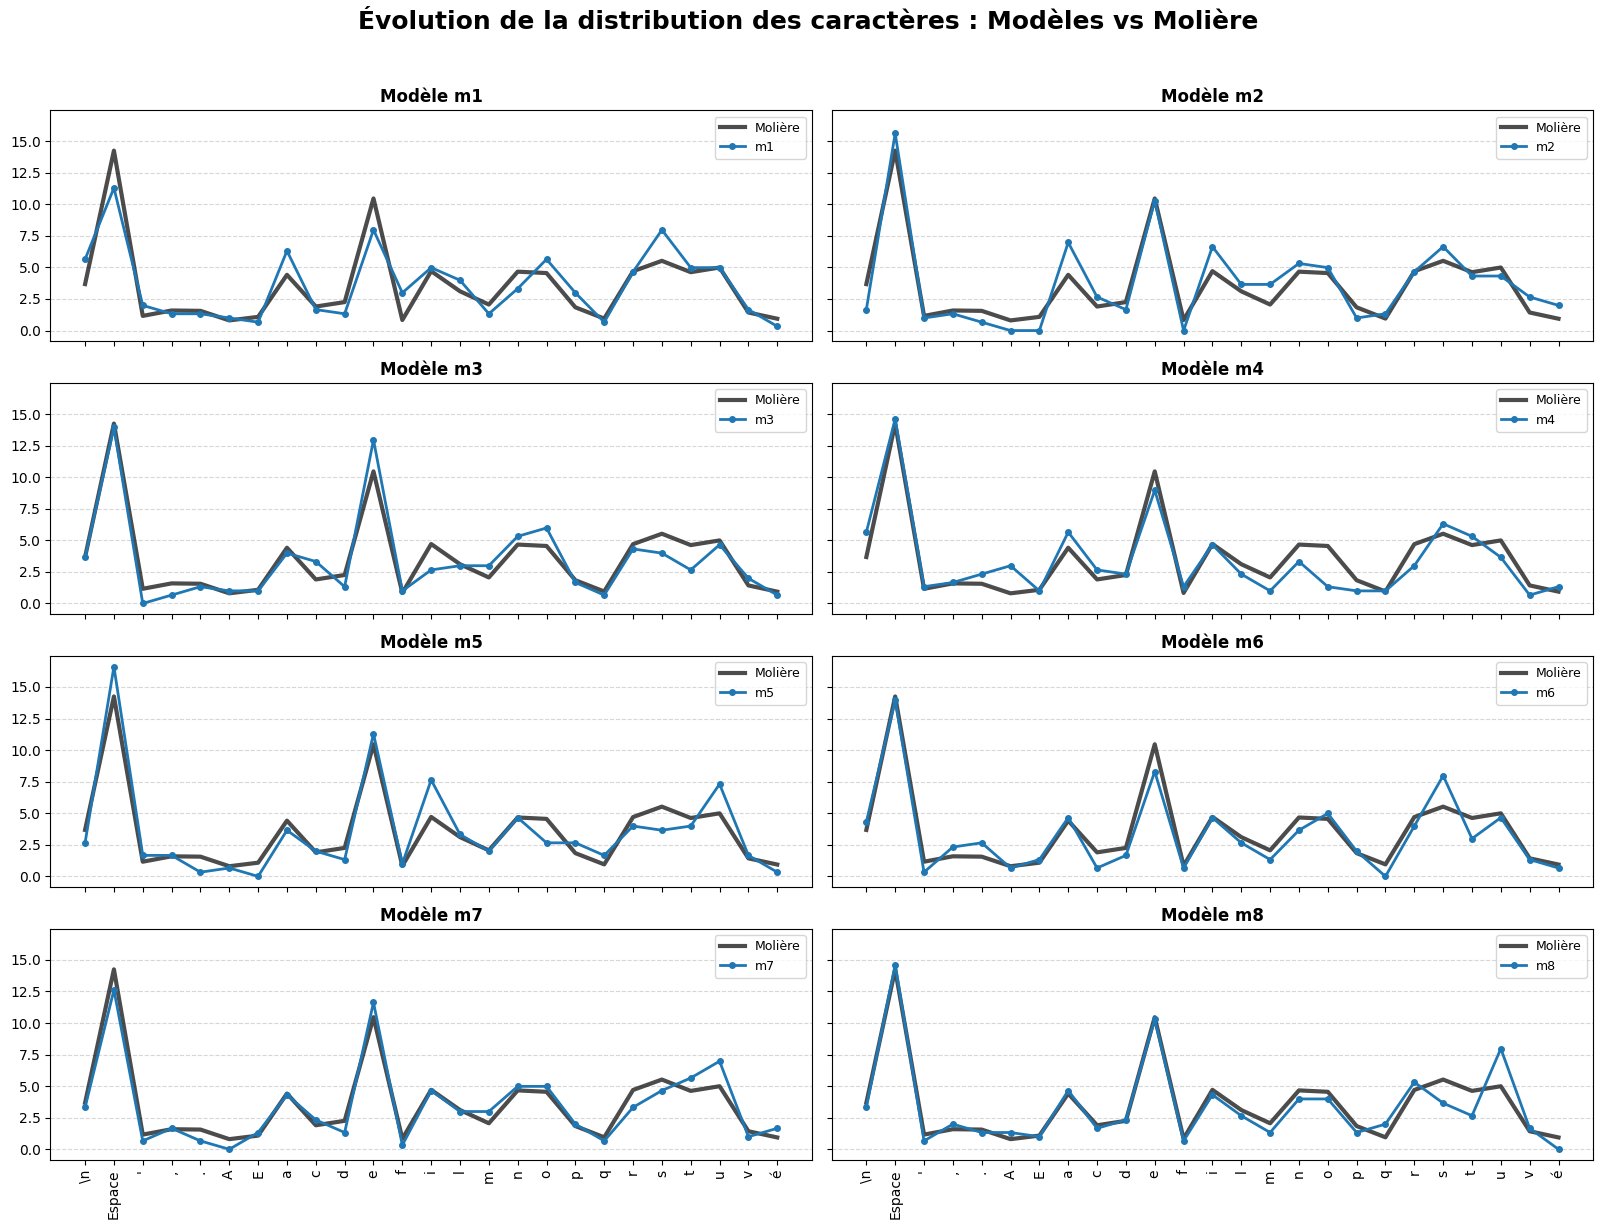

In [20]:
 tracer_evolution_subplots(text, resultat_repart_token)

In [25]:
modeles_a_comparer = ["m1","m2","m3", "m4","m5","m6","m7", "m8"]
prompt_comparaison = "Le roi dit :"
context_comp = torch.tensor(encode(prompt_comparaison), dtype=torch.long, device=device).unsqueeze(0)

tokens_a_generer_comp = 250 

print("================ COMPARAISON DES GÉNÉRATIONS ================\n")

for nom_modele in modeles_a_comparer:

    config_actuelle = next(c for c in configs_to_test if c['nom'] == nom_modele)

    block_size = config_actuelle['block_size']
    
    # 3. On charge et on génère
    m_test = modeles_sauvegardes[nom_modele]
    m_test.eval() 
    
    with torch.no_grad():
        idx_genere = m_test.generate(context_comp, max_new_tokens=tokens_a_generer_comp)
    
    texte_genere = decode(idx_genere[0].tolist())
    
    print(f"--- MODÈLE : {nom_modele} ---")
    print(f"Config : n_embd={config_actuelle['n_embd']}, n_head={config_actuelle['n_head']}, n_block={config_actuelle['n_block']}, block_size={block_size}")
    print("-" * 50)
    print(texte_genere)
    print("\n" + "=" * 60 + "\n")

================ COMPARAISON DES GÉNÉRATIONS ================

--- MODÈLE : m1 ---
Config : n_embd=64, n_head=4, n_block=3, block_size=16
--------------------------------------------------
Le roi dit : les je ne ganill?

LÉLIE. (Achi et
seur t l'y à von mi dépoinnez derbiens de les vins d'useroit deu pussee de cetittre vos bès j'ît l'éraptr'il suigne indar cérêcer detins...

ÉLIN..

Qui d'en de sout l'attouts ces arni éthoye.
.

Ce l'en dont intag


--- MODÈLE : m2 ---
Config : n_embd=64, n_head=4, n_block=3, block_size=64
--------------------------------------------------
Le roi dit : et Ainsanpuchésiel.

DO P'ayssise doncons248], par de ma voir poin des le grapendres savoice
Arme un la
gien dit son de hautarme.

Pourloit don moinseur rèc'esces b'heuffâce.
Mais; et mot s'es que pron pable peu cortie de salant dais_,
C'attantre, h


--- MODÈLE : m3 ---
Config : n_embd=128, n_head=4, n_block=3, block_size=64
--------------------------------------------------
Le roi dit : la vu chet vrai